# YZ50 Hafta 8: GPT'yi Tamamlıyoruz

Bu notebook **baştan sona tek parça** çalışır: `Runtime → Change runtime type → T4 GPU` seç, sonra `Runtime → Run all`.

**İçindekiler**

| Bölüm | Ne yapıyoruz | Videoda |
|---|---|---|
| 0 | Kurulum, veri, ortak fonksiyonlar, model parçaları | – |
| Görev 1 | Multi-head attention (tek head ile karşılaştırma) | 1:21:59 – 1:24:25 |
| Görev 2 | Transformer bloğu: feedforward, residual, LayerNorm (tek tablo) + LayerNorm / BatchNorm karşılaştırması | 1:24:25 – 1:37:49 |
| Görev 3 | Modeli büyüt + dropout (parametre, val loss, süre, örnek metin) | 1:37:49 – 1:42:39 |

Görev 4 (Türkçe metin) ve ek görev bu notebook'ta **yok**, ayrı yapılacak.

**Toplam süre:** T4 GPU'da yaklaşık 15-20 dakika.

**Not:** Tablolardaki modeller aynı seed ile eğitilir. Tek seed olduğu için çok küçük farklar (yaklaşık 0.01) gürültü olabilir; bunu Görev 2'de 3 farklı seed ile ayrıca kontrol ediyoruz.

## 0. Kurulum, veri ve ortak fonksiyonlar

In [1]:
import time, statistics, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.nn import functional as F
from IPython.display import display

# True yaparsan her şey birkaç saniyede biter (sadece kodun hatasız çalıştığını denemek için).
# Gerçek sonuçlar için False kalmalı.
HIZLI_TEST = False

# Her modeli yeniden eğitmek istemiyorsan seed kontrolünü (Görev 2'deki 6 ek eğitim) kapatabilirsin.
SEED_KONTROLU = True

KUCUK_ADIM = 60 if HIZLI_TEST else 5000      # küçük modellerin eğitim adımı
BIGRAM_ADIM = 100 if HIZLI_TEST else 10000   # bigram'ın eğitim adımı

device = 'cuda' if torch.cuda.is_available() else 'cpu'
if device == 'cuda':
    print("Cihaz: GPU ->", torch.cuda.get_device_name(0))
else:
    print("UYARI: GPU yok! Runtime > Change runtime type > T4 GPU seç. CPU'da Görev 3 çok yavaş olur.")

Cihaz: GPU -> Tesla T4


In [2]:
# Tiny Shakespeare verisini indir
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
urllib.request.urlretrieve(url, "input.txt")
with open("input.txt", "r", encoding="utf-8") as f:
    text = f.read()

# Karakter sözlüğü: her karaktere bir sayı veriyoruz
chars = sorted(list(set(text)))
vocab_size = len(chars)
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}
encode = lambda s: [stoi[c] for c in s]
decode = lambda l: ''.join([itos[i] for i in l])

# %90 eğitim, %10 doğrulama
data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9 * len(data))
train_data, val_data = data[:n], data[n:]

display(pd.DataFrame({
    "Bilgi": ["Toplam karakter", "Farklı karakter (vocab_size)", "Eğitim verisi", "Doğrulama verisi"],
    "Değer": [f"{len(text):,}".replace(",", "."), vocab_size,
              f"{len(train_data):,}".replace(",", "."), f"{len(val_data):,}".replace(",", ".")]
}))

,Bilgi,Değer
0,Toplam karakter,1.115.394
1,Farklı karakter (vocab_size),65
2,Eğitim verisi,1.003.854
3,Doğrulama verisi,111.540


**Ortak fonksiyonlar.**
- `get_batch`: rastgele parçalar seçer; her parçada giriş `x` ve bir harf kaydırılmış hedef `y` vardır.
- `estimate_loss`: 200 farklı batch üzerinde ortalama loss hesaplar (tek batch çok gürültülü olur). Dropout varsa kapatır.
- `kos`: bir modeli eğitir, train/val loss, parametre sayısı ve süreyi döndürür.
- `tablo`: sonuçları görsel tabloya çevirir; **Δ Val** önceki satıra göre farktır (eksi = iyileşme).

In [3]:
def get_batch(split, block_size, batch_size):
    d = train_data if split == 'train' else val_data
    ix = torch.randint(len(d) - block_size, (batch_size,))
    x = torch.stack([d[i:i + block_size] for i in ix])
    y = torch.stack([d[i + 1:i + block_size + 1] for i in ix])
    return x.to(device), y.to(device)


@torch.no_grad()
def estimate_loss(model, batch_size, eval_iters=200):
    out = {}
    model.eval()                      # dropout kapalı
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split, model.block_size, batch_size)
            _, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean().item()
    model.train()
    return out


def kos(isim, model_fn, adim, lr=1e-3, batch_size=32, seed=1337):
    """Modeli kurar, eğitir, değerlendirir. (sonuç sözlüğü, model) döndürür."""
    torch.manual_seed(seed)
    model = model_fn().to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr)
    t0 = time.time()
    for _ in range(adim):
        xb, yb = get_batch('train', model.block_size, batch_size)
        _, loss = model(xb, yb)
        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()
    sure = time.time() - t0
    r = estimate_loss(model, batch_size)
    params = sum(p.numel() for p in model.parameters())
    print(f"{isim:<40} adım={adim:<6} parametre={params:>9,}  train={r['train']:.4f}  val={r['val']:.4f}  ({sure:.0f} sn)")
    return dict(Model=isim, adim=adim, params=params, train=r['train'], val=r['val'], sure=sure), model


def etki(d):
    if d is None or pd.isna(d):
        return "–"
    if abs(d) < 0.01:
        return "fark çok küçük (gürültü sınırı)"
    return "iyileşti ↓" if d < 0 else "kötüleşti ↑"


def tablo(satirlar, video=None, baslik=None):
    """Sonuç sözlüklerinden görsel tablo yapar. video: videodaki yaklaşık val değerleri (isteğe bağlı)."""
    rows, prev = [], None
    for i, r in enumerate(satirlar):
        d = None if prev is None else r['val'] - prev
        row = {
            "Model": r['Model'],
            "Adım": r['adim'],
            "Parametre": f"{r['params']:,}".replace(",", "."),
            "Train loss": r['train'],
            "Val loss": r['val'],
            "Δ Val (önceki satıra göre)": np.nan if d is None else d,
            "Etki": etki(d),
        }
        if video is not None:
            row["Videoda (≈ val)"] = video[i]
        rows.append(row)
        prev = r['val']
    df = pd.DataFrame(rows)
    if baslik:
        print(baslik)
    fmt = {"Train loss": "{:.4f}", "Val loss": "{:.4f}", "Δ Val (önceki satıra göre)": "{:+.4f}"}
    if video is not None:
        fmt["Videoda (≈ val)"] = "{:.2f}"
    try:
        st = df.style.hide(axis='index').format(fmt, na_rep="–").highlight_min(subset=["Val loss"], color="#c8f7c5")
        display(st)
    except Exception:
        display(df)
    return df

**Model parçaları.** Hepsi tek yerde, her parça bir öncekinin üstüne eklenir:

- `Head`: tek bir self-attention head (key, query, value). Skorlar `head_size`'ın karekökü ile bölünür, böylece softmax çok sivri olmaz.
- `MultiHeadAttention`: birden fazla `Head`'i paralel çalıştırır, çıktıları yan yana birleştirir ve `proj` ile geri karıştırır.
- `FeedForward`: her harfin kendi başına "düşündüğü" küçük bir ağ (Linear → ReLU → Linear). İç boyut 4 katı büyüktür.
- `Block`: attention (iletişim) + feedforward (hesap). Üç bayrak vardır: `use_ffwd`, `use_res` (residual), `use_ln` (LayerNorm). Böylece tablodaki her satır **aynı kodla**, bir parça daha açılarak eğitilir.
- `GPT`: harf embedding + pozisyon embedding + `n_layer` blok + (isteğe bağlı) son LayerNorm + çıkış katmanı.

Ayarlar (`n_embd`, `block_size`, `dropout` ...) global değişken değil, `cfg(...)` sözlüğü ile verilir. Böylece Görev 3'te ayarları değiştirince eski modeller bozulmaz.

In [4]:
class BigramLanguageModel(nn.Module):
    """Sadece bir önceki harfe bakan en basit model."""
    def __init__(self, vocab_size):
        super().__init__()
        self.block_size = 8
        self.token_embedding_table = nn.Embedding(vocab_size, vocab_size)

    def forward(self, idx, targets=None):
        logits = self.token_embedding_table(idx)
        if targets is None:
            return logits, None
        B, T, C = logits.shape
        loss = F.cross_entropy(logits.view(B * T, C), targets.view(B * T))
        return logits, loss


class Head(nn.Module):
    """Tek bir self-attention head."""
    def __init__(self, n_embd, head_size, block_size, dropout):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, T, C = x.shape
        k = self.key(x)                                   # (B, T, head_size)
        q = self.query(x)                                 # (B, T, head_size)
        wei = q @ k.transpose(-2, -1) * k.shape[-1] ** -0.5   # (B, T, T), head_size ile ölçekle
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf'))  # gelecek görünmesin
        wei = F.softmax(wei, dim=-1)
        wei = self.dropout(wei)
        v = self.value(x)
        return wei @ v                                    # (B, T, head_size)


class MultiHeadAttention(nn.Module):
    """Birden fazla head paralel çalışır, çıktılar yan yana birleştirilir."""
    def __init__(self, n_embd, n_head, block_size, dropout):
        super().__init__()
        head_size = n_embd // n_head
        self.heads = nn.ModuleList([Head(n_embd, head_size, block_size, dropout) for _ in range(n_head)])
        self.proj = nn.Linear(n_head * head_size, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)   # kanal ekseninde birleştir
        return self.dropout(self.proj(out))


class FeedForward(nn.Module):
    """Her harf kendi başına, bağımsız olarak işlenir."""
    def __init__(self, n_embd, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


class Block(nn.Module):
    """İletişim (attention) + hesap (feedforward). Bayraklarla parça parça açılır."""
    def __init__(self, c):
        super().__init__()
        self.use_ffwd, self.use_res, self.use_ln = c['use_ffwd'], c['use_res'], c['use_ln']
        self.sa = MultiHeadAttention(c['n_embd'], c['n_head'], c['block_size'], c['dropout'])
        self.ffwd = FeedForward(c['n_embd'], c['dropout']) if self.use_ffwd else None
        self.ln1 = nn.LayerNorm(c['n_embd']) if self.use_ln else nn.Identity()
        self.ln2 = nn.LayerNorm(c['n_embd']) if (self.use_ln and self.use_ffwd) else nn.Identity()

    def forward(self, x):
        a = self.sa(self.ln1(x))                  # LayerNorm önce (pre-norm)
        x = x + a if self.use_res else a          # residual: x + f(x)
        if self.use_ffwd:
            f = self.ffwd(self.ln2(x))
            x = x + f if self.use_res else f
        return x


class GPT(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.block_size = c['block_size']
        self.token_embedding_table = nn.Embedding(c['vocab_size'], c['n_embd'])
        self.position_embedding_table = nn.Embedding(c['block_size'], c['n_embd'])
        self.blocks = nn.Sequential(*[Block(c) for _ in range(c['n_layer'])])
        self.ln_f = nn.LayerNorm(c['n_embd']) if c['use_ln'] else nn.Identity()   # çıkıştan önceki son LayerNorm
        self.lm_head = nn.Linear(c['n_embd'], c['vocab_size'])

    def forward(self, idx, targets=None):
        B, T = idx.shape
        tok = self.token_embedding_table(idx)
        pos = self.position_embedding_table(torch.arange(T, device=idx.device))
        x = self.blocks(tok + pos)
        logits = self.lm_head(self.ln_f(x))
        if targets is None:
            return logits, None
        B, T, C = logits.shape
        loss = F.cross_entropy(logits.view(B * T, C), targets.view(B * T))
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens):
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -self.block_size:]          # pozisyon tablosu block_size kadar, fazlasını kes
            logits, _ = self(idx_cond)
            probs = F.softmax(logits[:, -1, :], dim=-1)
            idx = torch.cat((idx, torch.multinomial(probs, num_samples=1)), dim=1)
        return idx


class Hafta7TekHead(nn.Module):
    """Geçen haftaki model: embedding -> tek head (head_size = n_embd, proj yok) -> çıkış."""
    def __init__(self, vocab_size, n_embd=32, block_size=8):
        super().__init__()
        self.block_size = block_size
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.sa_head = Head(n_embd, n_embd, block_size, 0.0)
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        x = self.token_embedding_table(idx) + self.position_embedding_table(torch.arange(T, device=idx.device))
        logits = self.lm_head(self.sa_head(x))
        if targets is None:
            return logits, None
        B, T, C = logits.shape
        return logits, F.cross_entropy(logits.view(B * T, C), targets.view(B * T))


def cfg(**kw):
    """Küçük model için varsayılan ayarlar. İstediğini değiştirerek kullan."""
    c = dict(vocab_size=vocab_size, n_embd=32, n_head=4, n_layer=1, block_size=8, dropout=0.0,
             use_ffwd=False, use_res=False, use_ln=False)
    c.update(kw)
    return c

print("Model parçaları hazır.")

Model parçaları hazır.


## Görev 1: Multi-head attention
*(Video 1:21:59 – 1:24:25)*

**Fikir:** Geçen hafta tek bir self-attention head vardı; her harf geçmişe tek bir "bakışla" bakıyordu. Multi-head'de bu bakışı çoğaltıyoruz:

1. 32 boyutlu embedding 4 parçaya bölünür (her head 8 boyut).
2. Her head kendi key / query / value matrisleriyle **kendi başına** attention yapar.
3. 4 head'in çıktıları yan yana birleştirilir (`torch.cat`, 4 × 8 = 32 boyut) ve `proj` katmanından geçer.

Böylece harfler birbirleriyle aynı anda **birden fazla kanaldan** konuşabilir (biri ünlülere, biri kelime başına, biri satır başındaki isme bakabilir gibi düşünülebilir).

Aşağıda önce bigram'ı, sonra geçen haftaki tek head'i, bu haftanın kodunda tek head'i (`n_head=1`) ve multi-head'i (`n_head=4`) aynı koşullarla eğitiyoruz.

In [5]:
sonuc = {}
sonuc['bigram'], _ = kos('bigram', lambda: BigramLanguageModel(vocab_size), BIGRAM_ADIM)
sonuc['h7'], _ = kos('tek head (Hafta 7 modeli)', lambda: Hafta7TekHead(vocab_size), KUCUK_ADIM)
sonuc['tek'], _ = kos('tek head (n_head=1)', lambda: GPT(cfg(n_head=1)), KUCUK_ADIM)
sonuc['multi'], _ = kos('multi-head (n_head=4)', lambda: GPT(cfg(n_head=4)), KUCUK_ADIM)

print("\nGÖREV 1: Geçen haftaki tek head ile multi-head yan yana")
df_g1 = tablo([sonuc['h7'], sonuc['tek'], sonuc['multi']])

bigram                                   adım=10000  parametre=    4,225  train=2.4623  val=2.4912  (20 sn)
tek head (Hafta 7 modeli)                adım=5000   parametre=    7,553  train=2.3868  val=2.4096  (17 sn)
tek head (n_head=1)                      adım=5000   parametre=    8,609  train=2.3917  val=2.4155  (19 sn)
multi-head (n_head=4)                    adım=5000   parametre=    8,609  train=2.2404  val=2.2671  (34 sn)

GÖREV 1: Geçen haftaki tek head ile multi-head yan yana


Model,Adım,Parametre,Train loss,Val loss,Δ Val (önceki satıra göre),Etki
tek head (Hafta 7 modeli),5000,7.553,2.3868,2.4096,–,–
tek head (n_head=1),5000,8.609,2.3917,2.4155,+0.0060,fark çok küçük (gürültü sınırı)
multi-head (n_head=4),5000,8.609,2.2404,2.2671,-0.1485,iyileşti ↓


**Nasıl okunur?**
- **Val loss** ne kadar küçükse model o kadar iyi.
- **Hafta 7 tek head** ile **tek head (n_head=1)** aynı fikir; küçük fark, bu haftaki kodda `proj` katmanı olmasından gelir.
- **tek head (n_head=1)** ile **multi-head (n_head=4)** satırlarının **parametre sayısı aynıdır**: head sayısı artınca toplam boyut aynı kalıyor (4 × 8 = 32). Aradaki val loss farkı parametre artışından değil, **yapıdan** gelir: aynı bütçeyle 4 ayrı "bakış".

## Görev 2: Transformer bloğu (feedforward, residual, LayerNorm)
*(Video 1:24:25 – 1:37:49)*

Bloğu parça parça kuruyoruz ve her parçadan sonra val loss'u kaydediyoruz. Her satır **tek bir şeyi** değiştirir:

| Parça | Ne işe yarar? |
|---|---|
| **Feedforward** | Attention harflerin birbirinden bilgi toplamasıdır (**iletişim**). Feedforward ise her harfin topladığı bilgiyi **kendi başına işlemesidir** (**hesap**). |
| **Blok yığma (3 katman)** | İletişim + hesabı üst üste 3 kez tekrarlar. Ağ derinleşir, ama derin ağlar eğitilmesi zor ağlardır. |
| **Residual (kestirme yol)** | `x = x + f(x)`. Girdi bloğun dışından da akar. Gradient toplama işlemlerinden engelsiz geçip girişe kadar ulaşır ("gradient otoyolu"), bu yüzden derin ağ eğitilebilir olur. |
| **LayerNorm** | Her harfin vektörünü kendi içinde normalize eder (ortalama 0, standart sapma 1). Değerlerin kontrolden çıkmasını önler. Burada **pre-norm** kullanıyoruz: LayerNorm, attention ve feedforward'dan **önce** uygulanır. Ayrıca çıkış katmanından önce bir son LayerNorm (`ln_f`) var. |

Videoda da ilk önce "feedforward" ekleniyor, ardından blokları üst üste koyunca eğitimin zorlaştığı (derin ağların optimizasyon sorunu) gösteriliyor, sonra residual ve LayerNorm çözüm olarak ekleniyor.

In [6]:
sonuc['ffwd1'], _ = kos('+ feedforward (1 katman)', lambda: GPT(cfg(n_head=4, n_layer=1, use_ffwd=True)), KUCUK_ADIM)
sonuc['katman3'], _ = kos('3 katman, residual yok', lambda: GPT(cfg(n_head=4, n_layer=3, use_ffwd=True)), KUCUK_ADIM)
sonuc['res'], _ = kos('+ residual (3 katman)', lambda: GPT(cfg(n_head=4, n_layer=3, use_ffwd=True, use_res=True)), KUCUK_ADIM)
sonuc['ln'], _ = kos('+ LayerNorm (3 katman)', lambda: GPT(cfg(n_head=4, n_layer=3, use_ffwd=True, use_res=True, use_ln=True)), KUCUK_ADIM)

+ feedforward (1 katman)                 adım=5000   parametre=   16,961  train=2.1660  val=2.1986  (37 sn)
3 katman, residual yok                   adım=5000   parametre=   41,921  train=2.2581  val=2.2746  (84 sn)
+ residual (3 katman)                    adım=5000   parametre=   41,921  train=1.9968  val=2.0778  (86 sn)
+ LayerNorm (3 katman)                   adım=5000   parametre=   42,369  train=1.9843  val=2.0680  (89 sn)


### Görev 2 tablosu: bigram → tek head → multi-head → feedforward → residual → LayerNorm

"Videoda (≈ val)" sütunu, Karpathy'nin videoda söylediği yaklaşık değerlerdir. Bizim değerlerle birebir aynı olması beklenmez (ayarlar ve seed farklı olabilir), sadece **sıranın ve eğilimin** benzer olup olmadığına bakıyoruz.

GÖREV 2: Basamak tablosu (hepsi aynı seed, aynı veri)


Model,Adım,Parametre,Train loss,Val loss,Δ Val (önceki satıra göre),Etki,Videoda (≈ val)
bigram,10000,4.225,2.4623,2.4912,–,–,2.50
tek head (n_head=1),5000,8.609,2.3917,2.4155,-0.0757,iyileşti ↓,2.40
multi-head (n_head=4),5000,8.609,2.2404,2.2671,-0.1485,iyileşti ↓,2.28
+ feedforward (1 katman),5000,16.961,2.1660,2.1986,-0.0684,iyileşti ↓,2.24
"3 katman, residual yok",5000,41.921,2.2581,2.2746,+0.0760,kötüleşti ↑,–
+ residual (3 katman),5000,41.921,1.9968,2.0778,-0.1968,iyileşti ↓,2.08
+ LayerNorm (3 katman),5000,42.369,1.9843,2.0680,-0.0098,fark çok küçük (gürültü sınırı),2.06


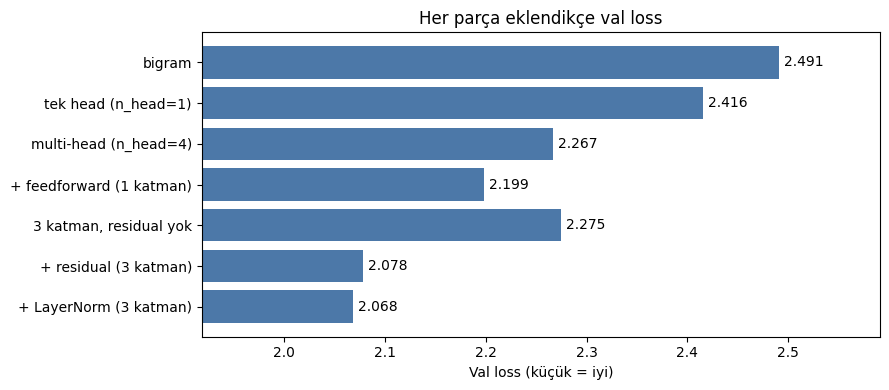

In [7]:
sirali = [sonuc['bigram'], sonuc['tek'], sonuc['multi'], sonuc['ffwd1'], sonuc['katman3'], sonuc['res'], sonuc['ln']]
video_degerleri = [2.5, 2.4, 2.28, 2.24, np.nan, 2.08, 2.06]   # videoda söylenen yaklaşık değerler (3 katman için sayı verilmedi)

print("GÖREV 2: Basamak tablosu (hepsi aynı seed, aynı veri)")
df_g2 = tablo(sirali, video=video_degerleri)

# Görsel: val loss çubukları
fig, ax = plt.subplots(figsize=(9, 4))
adlar = [r['Model'] for r in sirali]
vals = [r['val'] for r in sirali]
ax.barh(adlar, vals, color="#4c78a8")
ax.invert_yaxis()
ax.set_xlim(min(vals) - 0.15, max(vals) + 0.1)
for i, v in enumerate(vals):
    ax.text(v + 0.005, i, f"{v:.3f}", va="center")
ax.set_xlabel("Val loss (küçük = iyi)")
ax.set_title("Her parça eklendikçe val loss")
plt.tight_layout()
plt.show()

**Tabloyu okurken dikkat edilecekler**
- **Δ Val** sütununa bak: eksi ise o parça modeli iyileştirmiştir, artı ise kötüleştirmiştir.
- **Parametre** sütununa bak: residual ve LayerNorm eklenince parametre neredeyse hiç değişmez; yani oradaki kazanç "daha çok parametre"den değil, **bağlantı biçiminden** gelir.
- "3 katman, residual yok" satırı: derinleşmek tek başına yetmez, derin ağın eğitilebilmesi için residual gerekir.
- Train loss ile Val loss arasındaki fark büyümeye başlarsa model ezberlemeye başlıyor demektir (bunun için Görev 3'te dropout kullanacağız).
- Tek seed kullandık: **0.01 civarı farklar gürültü olabilir**. Bunu aşağıda ayrıca kontrol ediyoruz.

### Ek kontrol: LayerNorm farkı gerçek mi, gürültü mü?

LayerNorm'un katkısı küçük çıkabilir. Tek bir eğitimle "iyileşti" demek yerine, aynı iki modeli (LayerNorm yok / var) **3 farklı seed** ile eğitip ortalamalarına bakıyoruz.

In [8]:
if SEED_KONTROLU:
    satirlar = []
    ort = {}
    for ln_var in (False, True):
        vals = []
        for s in (1, 2, 3):
            r, _ = kos(f"3 katman + residual, LayerNorm={'var' if ln_var else 'yok'}, seed={s}",
                       lambda: GPT(cfg(n_head=4, n_layer=3, use_ffwd=True, use_res=True, use_ln=ln_var)),
                       KUCUK_ADIM, seed=s)
            vals.append(r['val'])
        ort[ln_var] = (statistics.mean(vals), statistics.stdev(vals))
        satirlar.append({"LayerNorm": "var" if ln_var else "yok",
                         "Val (seed 1)": vals[0], "Val (seed 2)": vals[1], "Val (seed 3)": vals[2],
                         "Ortalama": ort[ln_var][0], "Std": ort[ln_var][1]})
    print("\nLayerNorm yok / var: 3 seed karşılaştırması")
    df_seed = pd.DataFrame(satirlar)
    try:
        display(df_seed.style.hide(axis='index').format({c: "{:.4f}" for c in df_seed.columns if c != "LayerNorm"}))
    except Exception:
        display(df_seed)
    fark = ort[True][0] - ort[False][0]
    std_max = max(ort[False][1], ort[True][1])
    print(f"Ortalama fark (LayerNorm var - yok): {fark:+.4f}   |   en büyük std: {std_max:.4f}")
    if abs(fark) > 2 * std_max:
        yon = "iyileştirdi" if fark < 0 else "kötüleştirdi"
        print(f"Sonuç: fark seed'ler arasındaki oynamadan belirgin büyük; LayerNorm bu ağda val loss'u {yon}.")
    else:
        print("Sonuç: fark seed'ler arasındaki oynama ile aynı büyüklükte; bu küçük ağda LayerNorm'un etkisi belirsiz/küçük.")
else:
    print("SEED_KONTROLU=False olduğu için atlandı.")

3 katman + residual, LayerNorm=yok, seed=1 adım=5000   parametre=   41,921  train=1.9934  val=2.0807  (85 sn)
3 katman + residual, LayerNorm=yok, seed=2 adım=5000   parametre=   41,921  train=1.9944  val=2.0745  (86 sn)
3 katman + residual, LayerNorm=yok, seed=3 adım=5000   parametre=   41,921  train=2.0015  val=2.0796  (86 sn)
3 katman + residual, LayerNorm=var, seed=1 adım=5000   parametre=   42,369  train=1.9853  val=2.0648  (91 sn)
3 katman + residual, LayerNorm=var, seed=2 adım=5000   parametre=   42,369  train=1.9800  val=2.0522  (90 sn)
3 katman + residual, LayerNorm=var, seed=3 adım=5000   parametre=   42,369  train=1.9840  val=2.0687  (91 sn)

LayerNorm yok / var: 3 seed karşılaştırması


LayerNorm,Val (seed 1),Val (seed 2),Val (seed 3),Ortalama,Std
yok,2.0807,2.0745,2.0796,2.0783,0.0033
var,2.0648,2.0522,2.0687,2.0619,0.0086


Ortalama fark (LayerNorm var - yok): -0.0164   |   en büyük std: 0.0086
Sonuç: fark seed'ler arasındaki oynama ile aynı büyüklükte; bu küçük ağda LayerNorm'un etkisi belirsiz/küçük.


### LayerNorm ile BatchNorm1d (Hafta 6) karşılaştırması

İkisi de aktivasyonları ortalama 0, standart sapma 1 olacak şekilde normalize eder. Fark: **hangi eksende** normalize ettikleri.

| | BatchNorm1d (Hafta 6) | LayerNorm (bu hafta) |
|---|---|---|
| Normalize ettiği eksen | **Batch ekseni**: her nöron (sütun), batch'teki örneklere bakarak normalize edilir | **Özellik ekseni**: her örnek (satır), kendi içindeki özelliklere bakarak normalize edilir |
| Bir örneğin çıktısı diğer örneklere bağlı mı? | Evet (batch'in ortalaması kullanılır) | Hayır, her örnek bağımsız |
| `running_mean` / `running_var` | Tutar (test zamanı kullanmak için) | **Tutmaz** |
| Train ve test (eval) farkı | Var | Yok |

**Neden LayerNorm `running_mean` tutmuyor?** Çünkü ortalama ve varyansı zaten **tek bir örneğin kendi vektöründen** hesaplıyor, başka örneğe ihtiyacı yok. BatchNorm'da ise test zamanında elimizde batch olmayabilir (metin üretirken tek bir bağlamla çalışıyoruz), bu yüzden eğitimde biriktirilmiş `running_mean/var` kullanmak zorunda kalır. LayerNorm'da böyle bir sorun yok, eğitimde ve testte aynı hesabı yapar.

Aşağıdaki küçük deneyle bunu kendi gözümüzle görelim:

In [9]:
torch.manual_seed(1337)
x = torch.randn(32, 100) * 3 + 5          # 32 örnek, 100 özellik; ortalaması 5, std'si 3 (normalize EDİLMEMİŞ)

bn = nn.BatchNorm1d(100)                  # Hafta 6'da elle yazdığımızın aynısı
ln = nn.LayerNorm(100)

y_bn = bn(x)                              # eğitim modunda
y_ln = ln(x)

def ort_std(v):
    return f"{v.mean().item():+.3f}  /  {torch.std(v, correction=0).item():.3f}"

print("1) Hangi eksen normalize ediliyor?  (ortalama / std)")
display(pd.DataFrame({
    "Katman": ["BatchNorm1d", "LayerNorm"],
    "0. SÜTUN (bir özellik, 32 örnek boyunca)": [ort_std(y_bn[:, 0]), ort_std(y_ln[:, 0])],
    "0. SATIR (bir örnek, 100 özellik boyunca)": [ort_std(y_bn[0, :]), ort_std(y_ln[0, :])],
}))
print("-> BatchNorm1d sütunları (batch ekseni), LayerNorm satırları (özellik ekseni) normalize eder.")

print("\n2) Biriktirilen istatistik (buffer) var mı?")
display(pd.DataFrame({
    "Katman": ["BatchNorm1d", "LayerNorm"],
    "Buffer'lar": [", ".join(n for n, _ in bn.named_buffers()) or "yok",
                   ", ".join(n for n, _ in ln.named_buffers()) or "yok"],
}))

print("\n3) Eğitim modu ile test (eval) modu çıktıları aynı mı?")
bn.eval(); ln.eval()
fark_bn = (bn(x) - y_bn).abs().max().item()
fark_ln = (ln(x) - y_ln).abs().max().item()
display(pd.DataFrame({
    "Katman": ["BatchNorm1d", "LayerNorm"],
    "Train ile eval çıktısı arasındaki en büyük fark": [f"{fark_bn:.4f}", f"{fark_ln:.4f}"],
}))
print("-> BatchNorm için fark var (eval'de running_mean/var kullanılıyor), LayerNorm için fark 0.")

1) Hangi eksen normalize ediliyor?  (ortalama / std)


,Katman,"0. SÜTUN (bir özellik, 32 örnek boyunca)","0. SATIR (bir örnek, 100 özellik boyunca)"
0,BatchNorm1d,+0.000 / 1.000,+0.042 / 1.054
1,LayerNorm,+0.148 / 0.871,+0.000 / 1.000


-> BatchNorm1d sütunları (batch ekseni), LayerNorm satırları (özellik ekseni) normalize eder.

2) Biriktirilen istatistik (buffer) var mı?


,Katman,Buffer'lar
0,BatchNorm1d,"running_mean, running_var, num_batches_tracked"
1,LayerNorm,yok



3) Eğitim modu ile test (eval) modu çıktıları aynı mı?


,Katman,Train ile eval çıktısı arasındaki en büyük fark
0,BatchNorm1d,7.8451
1,LayerNorm,0.0000


-> BatchNorm için fark var (eval'de running_mean/var kullanılıyor), LayerNorm için fark 0.


## Görev 3: Modeli büyüt + dropout
*(Video 1:37:49 – 1:42:39)*

Şimdiye kadar çok küçük bir model kullandık (`n_embd=32`, `block_size=8`). Burada modeli büyütüyoruz. Büyütürken seçtiğimiz ayarlar:

| Ayar | Anlamı |
|---|---|
| `n_embd` | Her harfi temsil eden vektörün boyutu (modelin "genişliği") |
| `n_head` | Kaç head paralel çalışacak. `head_size = n_embd / n_head` |
| `n_layer` | Kaç blok üst üste konacak (modelin "derinliği") |
| `block_size` | Model bir harfi tahmin ederken en fazla kaç önceki harfe bakabilir (bağlam uzunluğu) |
| `batch_size` | Her adımda aynı anda kaç parça eğitilir |
| `dropout` | Eğitirken ara hesapların bir kısmını rastgele sıfırlama oranı |
| `learning_rate` | Öğrenme adımının büyüklüğü. Model büyüyünce küçültülür |

**Dropout nedir?** Eğitimde her adımda nöronların rastgele %20'si kapatılır. Model tek bir yola aşırı güvenemez, bu da **ezberlemeyi (overfitting) azaltır**. Test (eval) sırasında dropout kapalıdır, tüm nöronlar çalışır.

**Neden bu ayarlar?** Videodaki model 6 katman, 384 boyut, 256 bağlam ile A100 GPU'da yaklaşık 15 dakika sürüyor. Bizim ücretsiz Colab T4'ümüz daha yavaş, bu yüzden:
- `n_embd` 384 → **256**, `n_layer` 6 → **4**, `n_head` 6 → **4** (head_size yine **64**, videodaki gibi),
- `block_size` 256 → **128**: attention'ın maliyeti `block_size`'ın **karesiyle** büyür (her harf her harfe bakar, T×T matris), bağlamı yarıya indirmek maliyeti ciddi düşürür,
- `batch_size`, `dropout` (0.2) videodaki gibi **aynı**, `learning_rate` model büyüdüğü için **küçük** (3e-4).

Önce iki konfigürasyonu ve parametre sayılarını yan yana görelim. Karpathy'nin modelini eğitmiyoruz, sadece parametre sayısını hesaplıyoruz.

In [10]:
if HIZLI_TEST:
    BIG = dict(batch_size=16, block_size=32, n_embd=64, n_head=4, n_layer=2, dropout=0.2,
               lr=3e-4, max_iters=40, eval_interval=20, eval_iters=5)
else:
    BIG = dict(batch_size=64, block_size=128, n_embd=256, n_head=4, n_layer=4, dropout=0.2,
               lr=3e-4, max_iters=5000, eval_interval=500, eval_iters=50)

def tam_cfg(n_embd, n_head, n_layer, block_size, dropout):
    return cfg(n_embd=n_embd, n_head=n_head, n_layer=n_layer, block_size=block_size, dropout=dropout,
               use_ffwd=True, use_res=True, use_ln=True)

big_cfg = tam_cfg(BIG['n_embd'], BIG['n_head'], BIG['n_layer'], BIG['block_size'], BIG['dropout'])
karpathy_cfg = tam_cfg(384, 6, 6, 256, 0.2)

def param_say(c):
    m = GPT(c)                      # sadece sayım için (CPU'da kurulur, eğitilmez)
    p = sum(x.numel() for x in m.parameters())
    del m
    return p

p_big, p_karpathy = param_say(big_cfg), param_say(karpathy_cfg)

print("Konfigürasyon karşılaştırması")
df_cfg = pd.DataFrame({
    "Ayar": ["n_embd", "n_head", "head_size", "n_layer", "block_size", "batch_size", "dropout", "learning rate", "Parametre sayısı"],
    "Karpathy (video)": [384, 6, 64, 6, 256, 64, 0.2, "biraz düşürülmüş", f"{p_karpathy/1e6:.2f} M"],
    "Benim modelim": [BIG['n_embd'], BIG['n_head'], BIG['n_embd'] // BIG['n_head'], BIG['n_layer'], BIG['block_size'],
                      BIG['batch_size'], BIG['dropout'], BIG['lr'], f"{p_big/1e6:.2f} M"],
})
try:
    display(df_cfg.style.hide(axis='index'))
except Exception:
    display(df_cfg)

Konfigürasyon karşılaştırması


Ayar,Karpathy (video),Benim modelim
n_embd,384,256
n_head,6,4
head_size,64,64
n_layer,6,4
block_size,256,128
batch_size,64,64
dropout,0.200000,0.200000
learning rate,biraz düşürülmüş,0.000300
Parametre sayısı,10.79 M,3.22 M


**Süre ölçümü:** Büyük modeli eğitmeden önce 20 adım deneyip bir adımın kaç milisaniye sürdüğünü ölçüyoruz. Böylece toplam eğitim süresini önceden tahmin edebiliyoruz.

In [11]:
torch.manual_seed(1337)
tmp = GPT(big_cfg).to(device)
tmp_opt = torch.optim.AdamW(tmp.parameters(), lr=BIG['lr'])
if device == 'cuda': torch.cuda.synchronize()
t0 = time.time()
for _ in range(20):
    xb, yb = get_batch('train', BIG['block_size'], BIG['batch_size'])
    _, loss = tmp(xb, yb)
    tmp_opt.zero_grad(set_to_none=True)
    loss.backward()
    tmp_opt.step()
if device == 'cuda': torch.cuda.synchronize()
adim_ms = (time.time() - t0) / 20 * 1000
del tmp, tmp_opt
print(f"Bir adım: {adim_ms:.0f} ms  ->  {BIG['max_iters']} adım için tahmini süre ≈ {adim_ms * BIG['max_iters'] / 60000:.1f} dk")

Bir adım: 76 ms  ->  5000 adım için tahmini süre ≈ 6.4 dk


**Büyük modelin eğitimi.** Her `eval_interval` adımda train ve val loss'u yazdırıyoruz (bu ölçümler 200 değil, daha az batch ile yapıldığı için biraz gürültülüdür). Eğitim bitince 200 batch ile **kesin** değerleri ölçeceğiz.

In [12]:
torch.manual_seed(1337)
big_model = GPT(big_cfg).to(device)
n_params = sum(p.numel() for p in big_model.parameters())
print(f"Parametre sayısı: {n_params/1e6:.2f} M")

opt_big = torch.optim.AdamW(big_model.parameters(), lr=BIG['lr'])
gecmis = []
if device == 'cuda': torch.cuda.synchronize()
t_start = time.time()
for it in range(BIG['max_iters']):
    if it % BIG['eval_interval'] == 0 or it == BIG['max_iters'] - 1:
        r = estimate_loss(big_model, BIG['batch_size'], BIG['eval_iters'])
        gecmis.append({"Adım": it, "Train loss": r['train'], "Val loss": r['val'],
                       "Süre (dk)": (time.time() - t_start) / 60})
        print(f"adım {it:5d}: train {r['train']:.4f}, val {r['val']:.4f}  ({(time.time() - t_start) / 60:.1f} dk)")
    xb, yb = get_batch('train', BIG['block_size'], BIG['batch_size'])
    _, loss = big_model(xb, yb)
    opt_big.zero_grad(set_to_none=True)
    loss.backward()
    opt_big.step()
if device == 'cuda': torch.cuda.synchronize()
train_minutes = (time.time() - t_start) / 60
print(f"\nToplam eğitim süresi: {train_minutes:.1f} dk")
torch.save(big_model.state_dict(), "big_shakespeare.pt")

Parametre sayısı: 3.22 M
adım     0: train 4.2967, val 4.2913  (0.0 dk)
adım   500: train 2.0101, val 2.0681  (0.7 dk)
adım  1000: train 1.7110, val 1.8585  (1.5 dk)
adım  1500: train 1.5745, val 1.7405  (2.3 dk)
adım  2000: train 1.5002, val 1.6881  (3.1 dk)
adım  2500: train 1.4443, val 1.6388  (3.9 dk)
adım  3000: train 1.4101, val 1.6133  (4.7 dk)
adım  3500: train 1.3794, val 1.5754  (5.5 dk)
adım  4000: train 1.3592, val 1.5633  (6.3 dk)
adım  4500: train 1.3304, val 1.5595  (7.0 dk)
adım  4999: train 1.3134, val 1.5403  (7.8 dk)

Toplam eğitim süresi: 7.8 dk


Eğitim sırasında loss (azaltılmış batch ile ölçüm)


Adım,Train loss,Val loss,Süre (dk),Train-Val farkı
0,4.2967,4.2913,0.0,-0.0054
500,2.0101,2.0681,0.7,0.0580
1000,1.7110,1.8585,1.5,0.1475
1500,1.5745,1.7405,2.3,0.1660
2000,1.5002,1.6881,3.1,0.1879
2500,1.4443,1.6388,3.9,0.1945
3000,1.4101,1.6133,4.7,0.2032
3500,1.3794,1.5754,5.5,0.1960
4000,1.3592,1.5633,6.3,0.2041
4500,1.3304,1.5595,7.0,0.2292


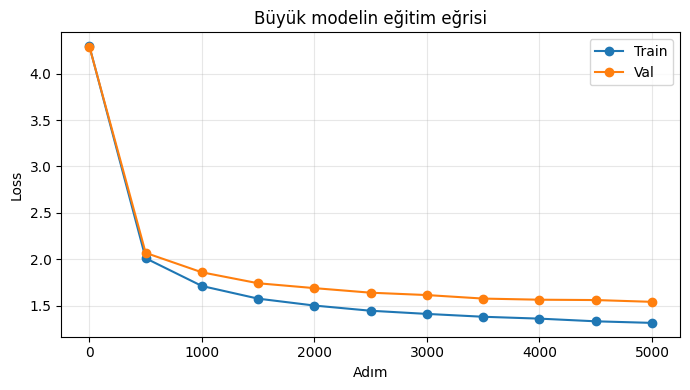

In [13]:
# Eğitim eğrisi tablosu ve grafiği
df_gecmis = pd.DataFrame(gecmis)
df_gecmis["Train-Val farkı"] = df_gecmis["Val loss"] - df_gecmis["Train loss"]
print("Eğitim sırasında loss (azaltılmış batch ile ölçüm)")
try:
    display(df_gecmis.style.hide(axis='index').format(
        {"Train loss": "{:.4f}", "Val loss": "{:.4f}", "Süre (dk)": "{:.1f}", "Train-Val farkı": "{:.4f}"}))
except Exception:
    display(df_gecmis)

plt.figure(figsize=(7, 4))
plt.plot(df_gecmis["Adım"], df_gecmis["Train loss"], marker="o", label="Train")
plt.plot(df_gecmis["Adım"], df_gecmis["Val loss"], marker="o", label="Val")
plt.xlabel("Adım"); plt.ylabel("Loss"); plt.title("Büyük modelin eğitim eğrisi")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

### Görev 3 sonuç tablosu: parametre sayısı, val loss, eğitim süresi

Final loss, 200 batch ile ölçülür (eğitim sırasındaki ölçümden daha güvenilirdir).

In [14]:
final = estimate_loss(big_model, BIG['batch_size'], 200)
gpu_adi = torch.cuda.get_device_name(0) if device == 'cuda' else 'CPU'

print("GÖREV 3: Sonuç")
df_g3 = pd.DataFrame({
    "": ["Parametre sayısı", "Val loss", "Train loss", "Eğitim süresi", "Cihaz", "Adım sayısı"],
    "Karpathy (video)": [f"{p_karpathy/1e6:.2f} M", "1.48", "–", "≈ 15 dk", "A100", "–"],
    "Benim modelim": [f"{n_params/1e6:.2f} M", f"{final['val']:.4f}", f"{final['train']:.4f}",
                      f"{train_minutes:.1f} dk", gpu_adi, BIG['max_iters']],
})
try:
    display(df_g3.style.hide(axis='index'))
except Exception:
    display(df_g3)

print(f"\nKüçük modelden (Görev 2, LayerNorm'lu satır) büyük modele val loss: {sonuc['ln']['val']:.4f} -> {final['val']:.4f}")
print(f"Train-Val farkı (büyük model): {final['val'] - final['train']:.4f}")

GÖREV 3: Sonuç


,Karpathy (video),Benim modelim
Parametre sayısı,10.79 M,3.22 M
Val loss,1.48,1.5510
Train loss,–,1.3168
Eğitim süresi,≈ 15 dk,7.8 dk
Cihaz,A100,Tesla T4
Adım sayısı,–,5000



Küçük modelden (Görev 2, LayerNorm'lu satır) büyük modele val loss: 2.0680 -> 1.5510
Train-Val farkı (büyük model): 0.2341


**Nasıl okunur?**
- Büyük model, küçük modele göre çok daha düşük val loss verir; çünkü hem **daha fazla parametresi** hem de **daha uzun bağlamı** (`block_size`) var.
- Karpathy'nin modeli bizimkinden büyük ve daha uzun eğitildiği için val loss'u daha da düşüktür. Bizimki küçültüldüğü için biraz geride kalır, bu beklenen bir durum.
- Eğitim eğrisi tablosundaki **Train-Val farkı** küçük kalıyorsa dropout ezberlemeyi kontrol altında tutuyor demektir.
- Eğrinin sonunda loss hâlâ düşüyorsa model tam yakınsamamıştır; daha fazla adımla biraz daha iyileşebilir.

### Modelin ürettiği metin

Aşağıda model boş bir başlangıçtan 600 harf üretiyor. Her çalıştırmada (seed değişirse) farklı metin çıkar.

In [15]:
big_model.eval()
torch.manual_seed(1337)
context = torch.zeros((1, 1), dtype=torch.long, device=device)
print(decode(big_model.generate(context, max_new_tokens=600)[0].tolist()))
big_model.train()



ANGELO:
And coward, O love to
be seem of our take rudes me?

Pause:
What is us he hand?

MERCUTIO:
Why crown?

PAULINA:
I must be some for the covert;
And but some entent, will it till vity and with her
Will joy well in your lovishment with prupe and plaw you:
You'll now patiently hope.
I think your oath so dud Coriolanus.

FLORIZEL:
No, gentle Coriolanus.

QUEEN ELIZABETH:
I am so. Why, my gentleman, which Prince, Somerry,--
I have you say advance.

EDWARD:
It is to make no very soldiers care,
One to the marriage of this eye so plant,
Nor poor by weath madam to stars in so life.

ISABELLA:
I


GPT(
  (token_embedding_table): Embedding(65, 256)
  (position_embedding_table): Embedding(128, 256)
  (blocks): Sequential(
    (0): Block(
      (sa): MultiHeadAttention(
        (heads): ModuleList(
          (0-3): 4 x Head(
            (key): Linear(in_features=256, out_features=64, bias=False)
            (query): Linear(in_features=256, out_features=64, bias=False)
            (value): Linear(in_features=256, out_features=64, bias=False)
            (dropout): Dropout(p=0.2, inplace=False)
          )
        )
        (proj): Linear(in_features=256, out_features=256, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
      )
      (ffwd): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=256, out_features=1024, bias=True)
          (1): ReLU()
          (2): Linear(in_features=1024, out_features=256, bias=True)
          (3): Dropout(p=0.2, inplace=False)
        )
      )
      (ln1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      

**Örnek metin nasıl yorumlanır?**
- Model oyun metninin **biçimini** öğrenmiş: büyük harfli karakter adı ve iki nokta, satır sonları, İngilizce'ye benzeyen kelimeler.
- Kelimelerin bir kısmı **uydurma** ve cümleler çoğunlukla **anlamlı değil**. Çünkü model harf harf çalışıyor ve sadece yaklaşık 1 milyon harflik küçük bir metinle, kısa sürede eğitildi.
- Yani model "anlamayı" değil, metnin **istatistiksel kalıbını** öğrendi. Daha büyük model ve daha çok veriyle (ChatGPT gibi) çıktı çok daha anlamlı olur.

## Özet

Bu notebook'ta Hafta 8'in Görev 1-3'ü tamamlandı:

1. **Multi-head attention:** Aynı parametre sayısıyla 4 ayrı bakış, tek head'e göre tabloda karşılaştırıldı.
2. **Transformer bloğu:** Feedforward, residual ve LayerNorm tek tabloda parça parça eklendi; LayerNorm farkı 3 seed ile kontrol edildi; LayerNorm ile BatchNorm1d küçük bir deneyle karşılaştırıldı.
3. **Büyük model + dropout:** Parametre sayısı, val loss, süre tablolandı; örnek metin üretildi.

Görev 4 (Türkçe metinle eğitim) ve ek görev ayrı notebook'ta yapılacak.